# 





In [1]:
import pandas as pd

train = pd.read_csv(r'C:\Users\Admin\Desktop\Walmart_Project\walmart-recruiting-store-sales-forecasting/train.csv')

train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [2]:
print(train.shape)

(421570, 5)


In [3]:
print(train.columns)

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'], dtype='object')


In [4]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB
None


In [5]:
train.describe()

,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


In [6]:
train.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

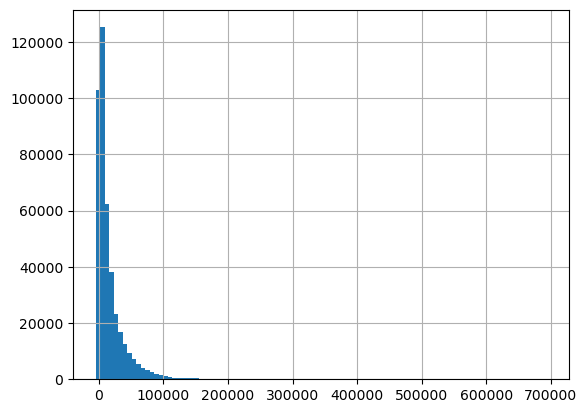

In [7]:
import matplotlib.pyplot as plt

train['Weekly_Sales'].hist(bins=100)
plt.show()


In [8]:
train.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head()

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
Name: Weekly_Sales, dtype: float64

In [9]:
train['Date'] = pd.to_datetime(train['Date'])

In [10]:
train['Year'] = train['Date'].dt.year
train['Month'] = train['Date'].dt.month
train['Week'] = train['Date'].dt.isocalendar().week

<Axes: xlabel='Month'>

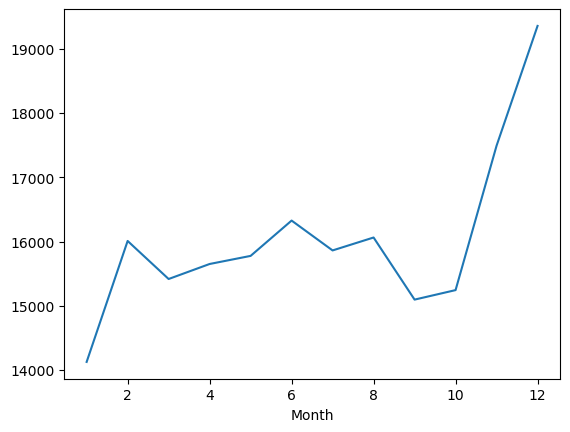

In [11]:
train.groupby('Month') ['Weekly_Sales'].mean().plot()

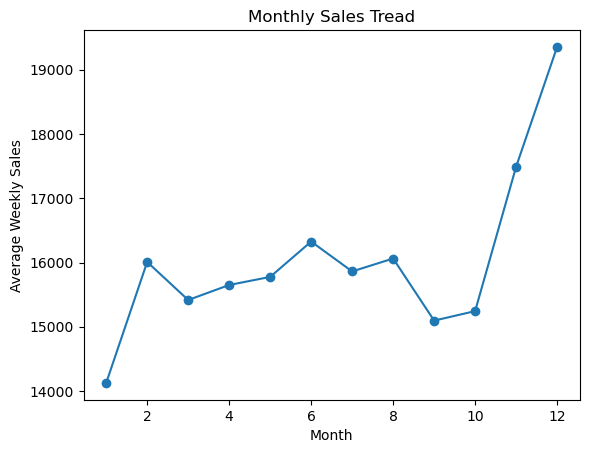

In [12]:
import matplotlib.pyplot as plt

train.groupby('Month') ['Weekly_Sales'].mean().plot(marker='o')
plt.title("Monthly Sales Tread")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.show()

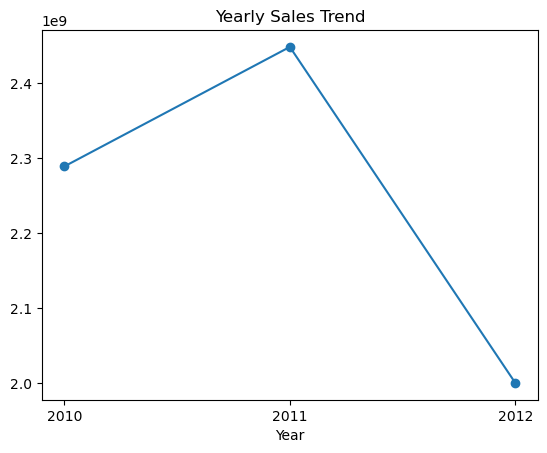

In [13]:
train.groupby('Year') ['Weekly_Sales'].sum().plot(marker=  "o"  )
plt.title("Yearly Sales Trend")
plt.xticks([2010, 2011, 2012])
plt.show()

In [14]:
train['Year'] =train['Year'].astype(int)

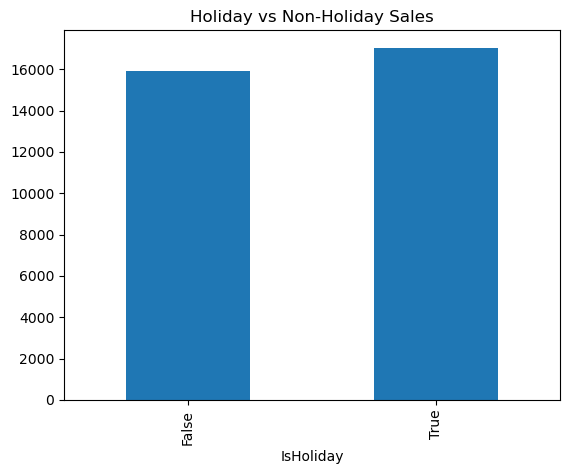

In [15]:
train.groupby('IsHoliday') ['Weekly_Sales'].mean().plot(kind='bar')
plt.title("Holiday vs Non-Holiday Sales")
plt.show()

In [16]:
import pandas as pd 

from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [17]:
X = train[['Store', 'Dept', 'Year', 'Month', 'Week']]
y = train['Weekly_Sales']

In [18]:
from sklearn.linear_model import LinearRegression


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [21]:
y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import r2_score

In [23]:
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.030604900068724072


In [24]:
from sklearn.ensemble import RandomForestRegressor

In [25]:
model = RandomForestRegressor(n_estimators=50)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50)

In [26]:
y_pred = model.predict(X_test)

In [27]:
print(r2_score(y_test, y_pred))

0.9684806089974956


In [28]:
import pandas as pd 

In [29]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)

In [30]:
print(feature_importance)

Store    0.370347
Dept     0.558581
Year     0.007876
Month    0.008424
Week     0.054773
dtype: float64


<Axes: >

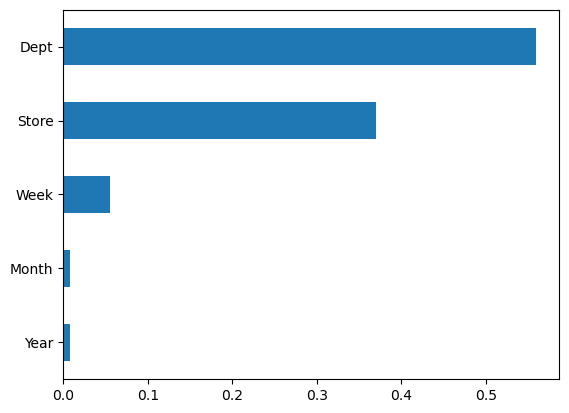

In [31]:
feature_importance.sort_values().plot(kind='barh')

In [32]:
train['IsHoliday'] = train['IsHoliday'].astype(int)

In [33]:
train[['IsHoliday']].head()

,IsHoliday
0,0
1,1
2,0
3,0
4,0


In [34]:
train.dtypes

Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                int32
Year                     int32
Month                    int32
Week                    UInt32
dtype: object

In [35]:
X = train[['Store', 'Dept', 'Year', 'Month', 'Week','IsHoliday']]

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train,Y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=42
)

In [37]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=50)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50)

In [38]:
y_pred = model.predict(X_test)

from sklearn.metrics import r2_score
print("New Score:", r2_score(y_test, y_pred))

New Score: 0.9700980843155397


In [39]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False)

Dept         0.558736
Store        0.370507
Week         0.050530
Month        0.010082
Year         0.007811
IsHoliday    0.002335
dtype: float64

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

linear_score = r2_score(y_test, y_pred)

print("Linear Done")

Linear Done


In [41]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=50)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rf_score = r2_score(y_test, y_pred)

print("RF Done")

RF Done


In [42]:
X_new = train[['Dept','Store','IsHoliday']]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=50)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

top_score = r2_score(y_test, y_pred)

print("Top Features Done")

Top Features Done


In [43]:
print("Linear:", linear_score)
print("Random Forest:", rf_score)
print("Top Features RF:", top_score)

Linear: 0.030709173636700893
Random Forest: 0.9688701679270849
Top Features RF: 0.9006806601379828


In [44]:
from sklearn.model_selection import GridSearchCV

In [45]:
params = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

In [46]:
rf = RandomForestRegressor()

grid = GridSearchCV(rf, params, cv=3, n_jobs=-1, verbose=2)

In [47]:
grid.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


GridSearchCV(cv=3, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]},
             verbose=2)

In [48]:
best_model = grid.best_estimator_

In [49]:
y_pred = best_model.predict(X_test)

from sklearn.metrics import r2_score
print("Tuned Score:", r2_score(y_test, y_pred))

Tuned Score: 0.9004726816797155


In [50]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [51]:
params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [52]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, max_depth=20)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import r2_score 
print("Final Score:", r2_score(y_test, y_pred))

Final Score: 0.9005207687153263


In [53]:
import pandas as pd 

submission = pd.DataFrame({
    "Id": range(len(y_pred)),
    "Weekly_Sales": y_pred
})

submission.to_csv("submission.csv",
                  index=False)

In [54]:
features = pd.read_csv(r'C:\Users\Admin\Desktop\Walmart_Project\walmart-recruiting-store-sales-forecasting\features_new.csv')
stores = pd.read_csv(r'C:\Users\Admin\Desktop\Walmart_Project\walmart-recruiting-store-sales-forecasting\stores.csv')


In [55]:

train['Date'] = pd.to_datetime(train['Date'])
features['Date'] = pd.to_datetime(features['Date'])

features = features.drop(columns=['IsHoliday'])

data = train.merge(stores, on='Store', how='left')
data = data.merge(features, on=['Store', 'Date'], how='left')

data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Week,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,0,2010,2,5,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,1,2010,2,6,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,0,2010,2,7,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,0,2010,2,8,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,0,2010,3,9,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


In [56]:
train['Date'] = pd.to_datetime(train['Date'])
features['Date'] = pd.to_datetime(features['Date'])

In [57]:
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Week'] = data['Date'].dt.isocalendar().week

data = data.drop(columns=['Date'])

In [58]:
data = data.fillna(0)

In [59]:
data = pd.get_dummies(data, columns=['Type'], drop_first=True)

In [60]:
features = ['Store', 'Dept', 'Size', 'Week', 'CPI']

X = data[features]
y = data['Weekly_Sales']


In [61]:
from sklearn.ensemble import RandomForestRegressor 

model = RandomForestRegressor()
model.fit(X, y)



RandomForestRegressor()

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [63]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [64]:
from sklearn.metrics import r2_score

print("Final Score:", r2_score(y_test, y_pred))

Final Score: 0.9631104219527481


In [65]:
import pandas as pd

submission = pd.DataFrame({
    "Id": range(len(y_pred)),
    "Weekly_Sales": y_pred
})

submission.to_csv("final_submission.csv", index=False)

In [66]:
importance = pd.DataFrame({
    'feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance.head(10)

,feature,Importance
1,Dept,0.642725
2,Size,0.200851
0,Store,0.071988
3,Week,0.052330
4,CPI,0.032106


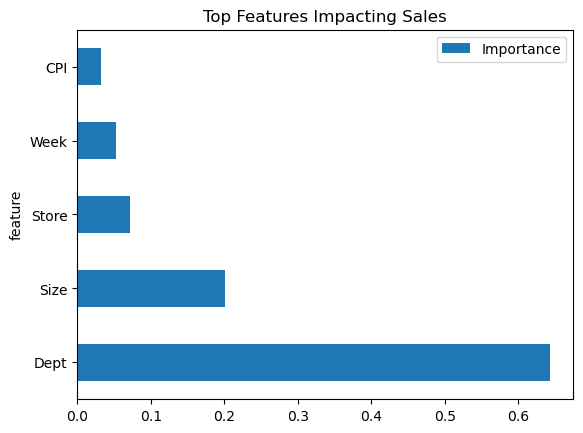

In [67]:
import matplotlib.pyplot as plt

importance.head(10).plot(kind='barh', x='feature', y='Importance')
plt.title("Top Features Impacting Sales")
plt.show()

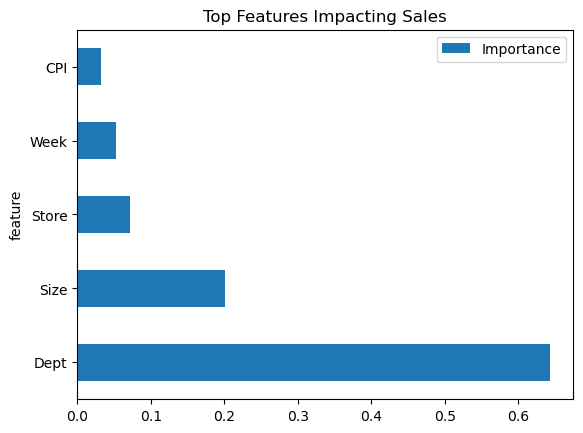

In [68]:
import matplotlib.pyplot as plt 

importance.head(10).plot(kind='barh', x='feature', y='Importance')
plt.title("Top Features Impacting Sales")
plt.show()

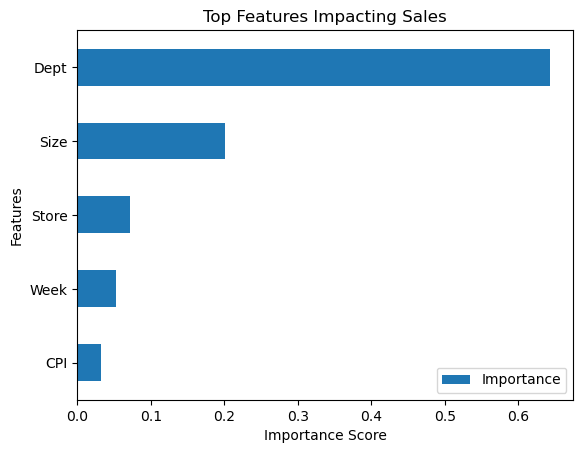

In [69]:
importance.head(10).sort_values(by='Importance').plot(
    kind='barh', x='feature', y='Importance'
)
plt.title("Top Features Impacting Sales")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [70]:
from sklearn.ensemble import  RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Linear R2:", r2_score(y_test,lr_pred))

print("RandomForest R2:", r2_score(y_test, rf_pred))

Linear R2: 0.08718019578954961
RandomForest R2: 0.9746493660438627


In [71]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: xgboost in c:\users\admin\anaconda3\lib\site-packages (3.0.4)



In [72]:
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=100)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

from sklearn.metrics import r2_score
print("XGBoost R2:", r2_score(y_test, xgb_pred))


XGBoost R2: 0.9471704215496266


In [73]:
features = ['Store','Dept','Size','Week','CPI']

X = data[features]
y = data['Weekly_Sales']



In [74]:
model.fit(X, y)

RandomForestRegressor(max_depth=15, n_jobs=-1)

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [76]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

RandomForestRegressor()

In [77]:
import joblib
joblib.dump(rf, "sales_model.pkl")

['sales_model.pkl']

In [ ]:
loaded_model = joblib.load("sales_model.pkl")

sample = X_test.iloc[0:5]

prediction = loaded_model.predict(sample)

print(prediction)